In [2]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
df = pd.read_pickle('../data/processed/master.pkl')
dfp = df[(df['price'] > 0) & (df['price'] < df['price'].quantile(0.99))].copy()
df.shape

(15293, 93)

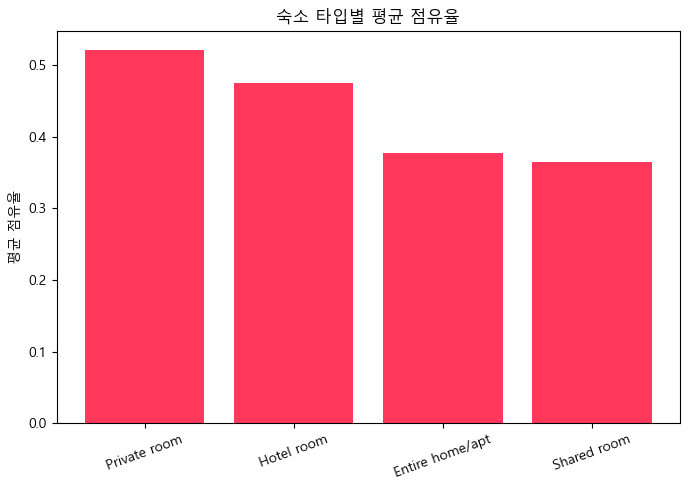

room_type
Private room       0.521391
Hotel room         0.475262
Entire home/apt    0.377488
Shared room        0.364729
Name: occupancy_rate, dtype: float64


In [4]:
rt = df.groupby('room_type')['occupancy_rate'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(rt.index, rt.values, color='#FF385C')
ax.set_title('숙소 타입별 평균 점유율')
ax.set_ylabel('평균 점유율')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('../outputs/q1_room_type.png', dpi=130)
plt.show()

print(rt)

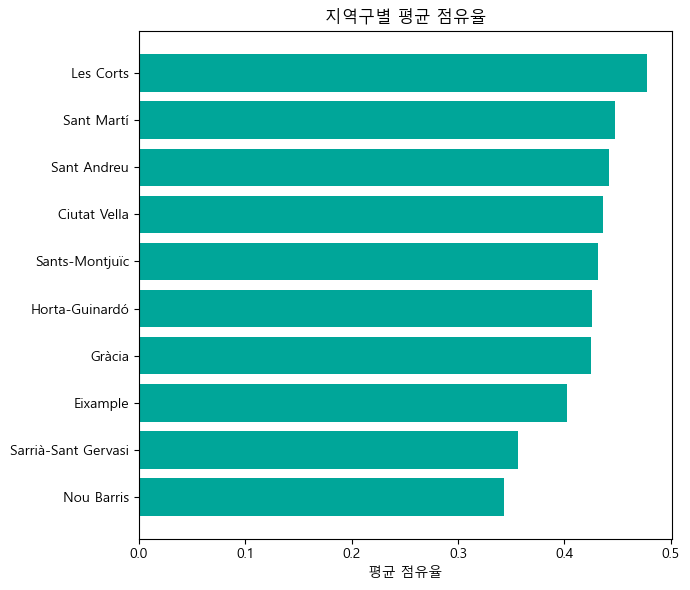

neighbourhood_group_cleansed
Les Corts              0.477324
Sant Martí             0.447888
Sant Andreu            0.441498
Ciutat Vella           0.436316
Sants-Montjuïc         0.431388
Horta-Guinardó         0.425645
Gràcia                 0.424467
Eixample               0.402134
Sarrià-Sant Gervasi    0.356744
Nou Barris             0.343373
Name: occupancy_rate, dtype: float64


In [5]:
ng = df.groupby('neighbourhood_group_cleansed')['occupancy_rate'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(ng.index[::-1], ng.values[::-1], color='#00A699')
ax.set_title('지역구별 평균 점유율')
ax.set_xlabel('평균 점유율')
plt.tight_layout()
plt.savefig('../outputs/q5_neighbourhood.png', dpi=130)
plt.show()

print(ng)

### 가격 vs 점유율

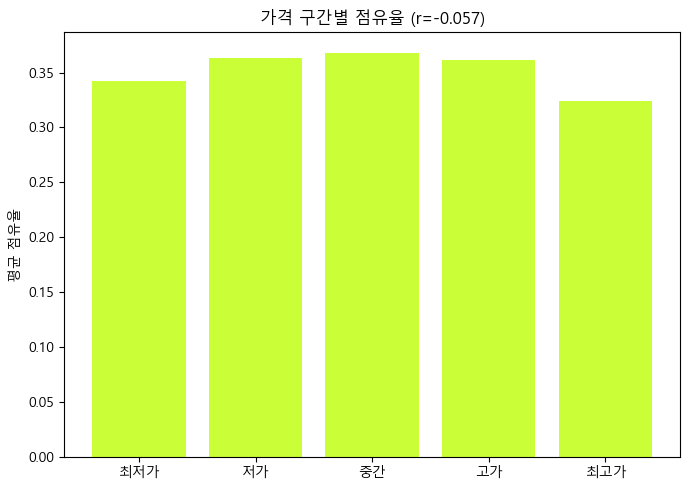

상관계수: -0.05717371361685383
price_bin
최저가    0.341977
저가     0.363327
중간     0.368184
고가     0.361446
최고가    0.323899
Name: occupancy_rate, dtype: float64


In [6]:
corr_price = dfp[['price', 'occupancy_rate']].corr().iloc[0, 1]
dfp['price_bin'] = pd.qcut(dfp['price'], 5, labels=['최저가','저가','중간','고가','최고가'])
pb = dfp.groupby('price_bin', observed=True)['occupancy_rate'].mean()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(pb.index.astype(str), pb.values, color="#CAFF38")
ax.set_title(f'가격 구간별 점유율 (r={corr_price:.3f})')
ax.set_ylabel('평균 점유율')
plt.tight_layout()
plt.savefig('../outputs/q2_price_bin.png', dpi=130)
plt.show()

print("상관계수:", corr_price)
print(pb)

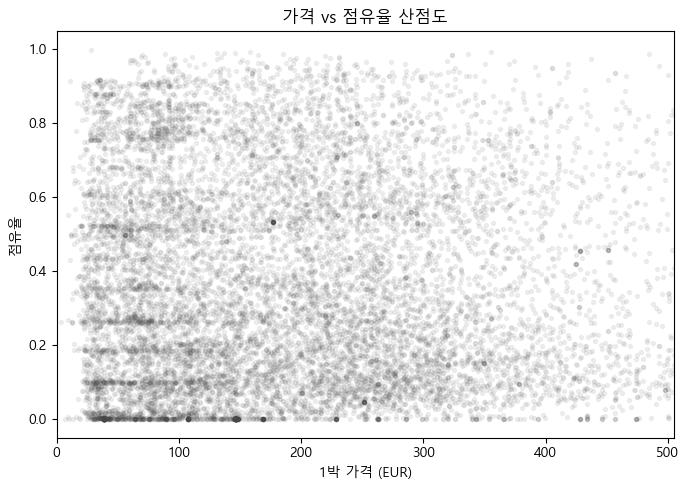

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(dfp['price'], dfp['occupancy_rate'], alpha=0.08, s=8, color='#484848')
ax.set_xlabel('1박 가격 (EUR)')
ax.set_ylabel('점유율')
ax.set_title('가격 vs 점유율 산점도')
ax.set_xlim(0, dfp['price'].quantile(0.95))
plt.tight_layout()
plt.savefig('../outputs/q2_price_scatter.png', dpi=130)
plt.show()

### 리뷰수 / 평점 vs 점유율

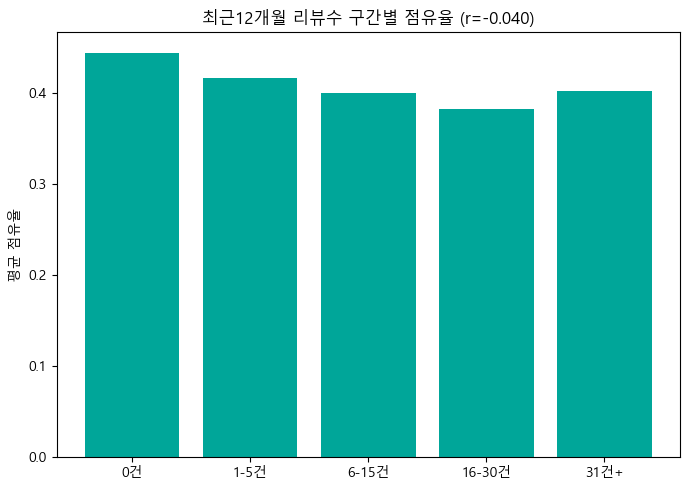

리뷰수 상관계수: -0.0402931621464391
rev_bin
0건        0.443843
1-5건      0.415811
6-15건     0.399243
16-30건    0.381506
31건+      0.401610
Name: occupancy_rate, dtype: float64


In [8]:
# 최근 12개월 리뷰 수 구간별 점유율
corr_rev = df[['number_of_reviews_ltm', 'occupancy_rate']].corr().iloc[0, 1]

df['rev_bin'] = pd.cut(df['number_of_reviews_ltm'], bins=[-1,0,5,15,30,10000],
                        labels=['0건','1-5건','6-15건','16-30건','31건+'])
rb = df.groupby('rev_bin', observed=True)['occupancy_rate'].mean()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(rb.index.astype(str), rb.values, color='#00A699')
ax.set_title(f'최근12개월 리뷰수 구간별 점유율 (r={corr_rev:.3f})')
ax.set_ylabel('평균 점유율')
plt.tight_layout()
plt.savefig('../outputs/q3_reviews_bin.png', dpi=130)
plt.show()

print("리뷰수 상관계수:", corr_rev)
print(rb)

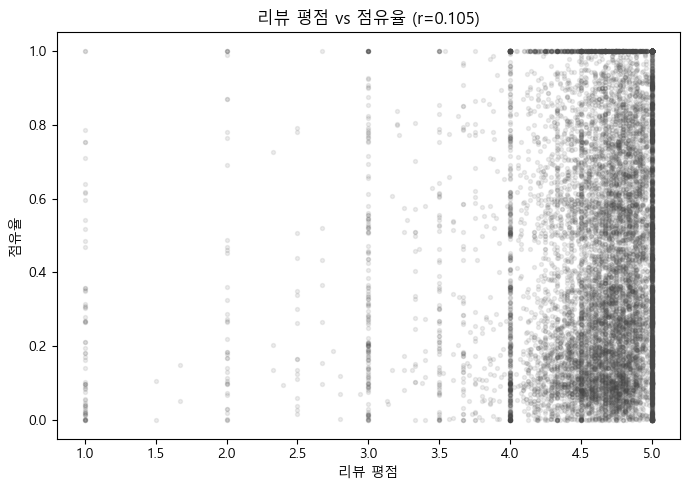

평점 상관계수: 0.10469024298598892


In [9]:
# 리뷰 평점 vs 점유율 산점도
corr_score = df[['review_scores_rating', 'occupancy_rate']].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['review_scores_rating'], df['occupancy_rate'], alpha=0.1, s=8, color='#484848')
ax.set_xlabel('리뷰 평점')
ax.set_ylabel('점유율')
ax.set_title(f'리뷰 평점 vs 점유율 (r={corr_score:.3f})')
plt.tight_layout()
plt.savefig('../outputs/q3_score_scatter.png', dpi=130)
plt.show()

print("평점 상관계수:", corr_score)

### Superhost 영향 (t-test)

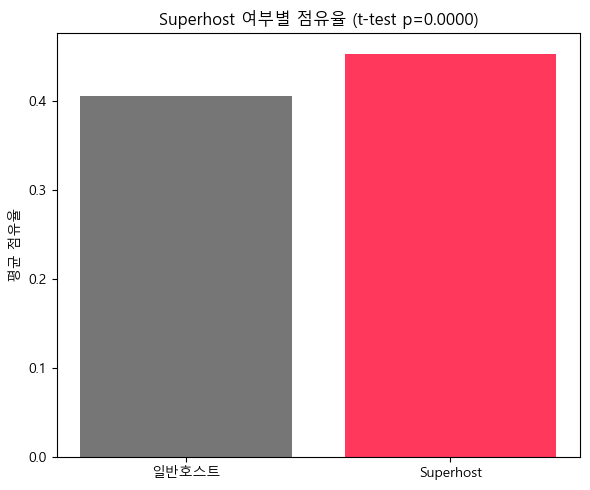

host_is_superhost
f    0.406069
t    0.453708
Name: occupancy_rate, dtype: float64
p-value: 1.7953945606487298e-17


In [10]:
sh = df.dropna(subset=['host_is_superhost'])
t_stat, p_val = stats.ttest_ind(
    sh.loc[sh['host_is_superhost']=='t', 'occupancy_rate'],
    sh.loc[sh['host_is_superhost']=='f', 'occupancy_rate'],
    equal_var=False
)
sh_occ = sh.groupby('host_is_superhost')['occupancy_rate'].mean()

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(['일반호스트','Superhost'], [sh_occ['f'], sh_occ['t']], color=['#767676','#FF385C'])
ax.set_title(f'Superhost 여부별 점유율 (t-test p={p_val:.4f})')
ax.set_ylabel('평균 점유율')
plt.tight_layout()
plt.savefig('../outputs/q4_superhost.png', dpi=130)
plt.show()

print(sh_occ)
print("p-value:", p_val)

### 최소숙박일 vs 점유율

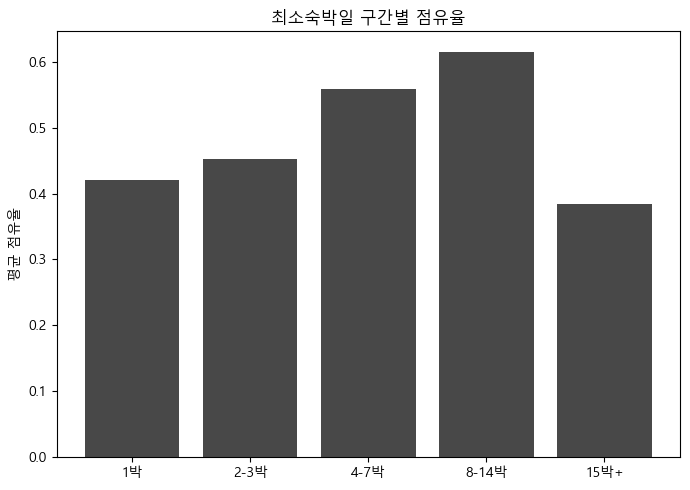

상관계수: -0.03203132599196074
min_nights_bin
1박       0.420936
2-3박     0.452864
4-7박     0.558944
8-14박    0.615199
15박+     0.383921
Name: occupancy_rate, dtype: float64


In [11]:
df['min_nights_bin'] = pd.cut(df['minimum_nights'], bins=[0,1,3,7,14,10000],
                                labels=['1박','2-3박','4-7박','8-14박','15박+'])
mn = df.groupby('min_nights_bin', observed=True)['occupancy_rate'].mean()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(mn.index.astype(str), mn.values, color='#484848')
ax.set_title('최소숙박일 구간별 점유율')
ax.set_ylabel('평균 점유율')
plt.tight_layout()
plt.savefig('../outputs/q6_min_nights.png', dpi=130)
plt.show()

corr_mn = df[['minimum_nights', 'occupancy_rate']].corr().iloc[0, 1]
print("상관계수:", corr_mn)
print(mn)

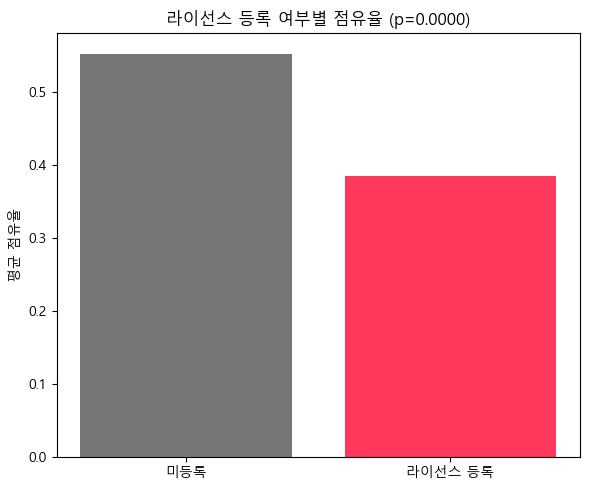

is_licensed
False    0.552211
True     0.384571
Name: occupancy_rate, dtype: float64
p-value: 1.4706508486600734e-95
라이선스 등록 비율: 0.801020074543909


In [12]:
# 라이선스(정식 등록번호) 보유 여부가 점유율에 영향을 주는가
df['is_licensed'] = df['license'].notna()

lic = df.groupby('is_licensed')['occupancy_rate'].mean()
t_lic, p_lic = stats.ttest_ind(
    df.loc[df['is_licensed']==True, 'occupancy_rate'].dropna(),
    df.loc[df['is_licensed']==False, 'occupancy_rate'].dropna(),
    equal_var=False
)

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(['미등록','라이선스 등록'], [lic[False], lic[True]], color=['#767676','#FF385C'])
ax.set_title(f'라이선스 등록 여부별 점유율 (p={p_lic:.4f})')
ax.set_ylabel('평균 점유율')
plt.tight_layout()
plt.savefig('../outputs/q8_license.png', dpi=130)
plt.show()

print(lic)
print("p-value:", p_lic)
print("라이선스 등록 비율:", df['is_licensed'].mean())

In [13]:
print("instant_bookable 결측률:", df['instant_bookable'].isnull().mean())

instant_bookable 결측률: 1.0


### 지표 정합성 검증: 예약 프록시 지표들의 상관관계

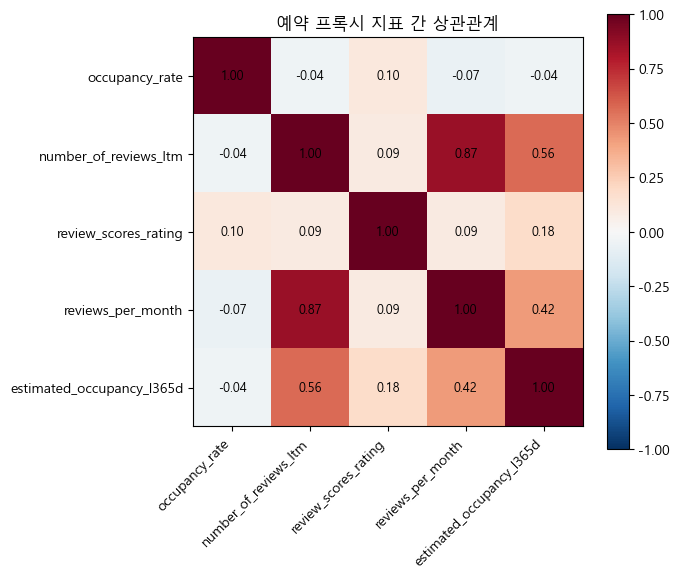

                           occupancy_rate  number_of_reviews_ltm  \
occupancy_rate                   1.000000              -0.040293   
number_of_reviews_ltm           -0.040293               1.000000   
review_scores_rating             0.104690               0.092441   
reviews_per_month               -0.066951               0.866247   
estimated_occupancy_l365d       -0.041119               0.564851   

                           review_scores_rating  reviews_per_month  \
occupancy_rate                         0.104690          -0.066951   
number_of_reviews_ltm                  0.092441           0.866247   
review_scores_rating                   1.000000           0.092207   
reviews_per_month                      0.092207           1.000000   
estimated_occupancy_l365d              0.184995           0.422768   

                           estimated_occupancy_l365d  
occupancy_rate                             -0.041119  
number_of_reviews_ltm                       0.564851  
revie

In [14]:
proxy_cols = ['occupancy_rate', 'number_of_reviews_ltm', 'review_scores_rating',
              'reviews_per_month', 'estimated_occupancy_l365d']
corr_matrix = df[proxy_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(proxy_cols)))
ax.set_yticks(range(len(proxy_cols)))
ax.set_xticklabels(proxy_cols, rotation=45, ha='right')
ax.set_yticklabels(proxy_cols)
for i in range(len(proxy_cols)):
    for j in range(len(proxy_cols)):
        ax.text(j, i, f'{corr_matrix.iloc[i,j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_title('예약 프록시 지표 간 상관관계')
plt.colorbar(im)
plt.tight_layout()
plt.savefig('../outputs/q_proxy_correlation.png', dpi=130)
plt.show()

print(corr_matrix)

### 호스트 세그먼트: 개인 호스트 vs 멀티(프로) 호스트

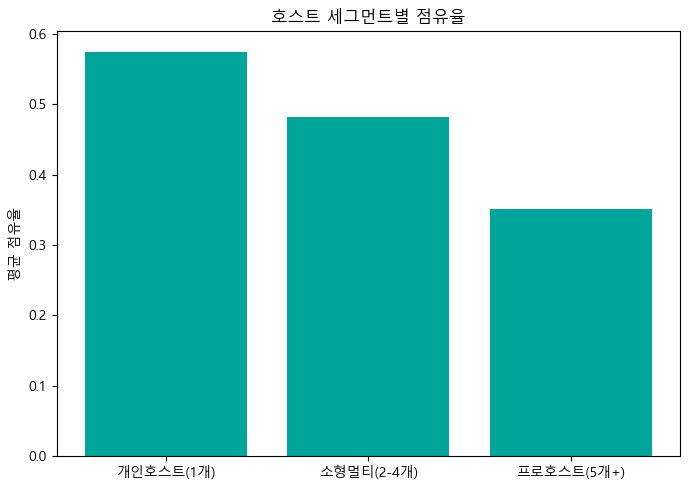

host_segment
개인호스트(1개)     0.574996
소형멀티(2-4개)    0.481476
프로호스트(5개+)    0.351715
Name: occupancy_rate, dtype: float64

세그먼트별 리스팅 수:
host_segment
개인호스트(1개)     2988
소형멀티(2-4개)    2662
프로호스트(5개+)    9643
dtype: int64


In [15]:
df['host_segment'] = pd.cut(df['calculated_host_listings_count'],
                              bins=[0, 1, 4, 10000],
                              labels=['개인호스트(1개)', '소형멀티(2-4개)', '프로호스트(5개+)'])

seg = df.groupby('host_segment', observed=True)['occupancy_rate'].mean()
seg_count = df.groupby('host_segment', observed=True).size()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(seg.index.astype(str), seg.values, color='#00A699')
ax.set_title('호스트 세그먼트별 점유율')
ax.set_ylabel('평균 점유율')
plt.tight_layout()
plt.savefig('../outputs/q_host_segment.png', dpi=130)
plt.show()

print(seg)
print()
print("세그먼트별 리스팅 수:")
print(seg_count)

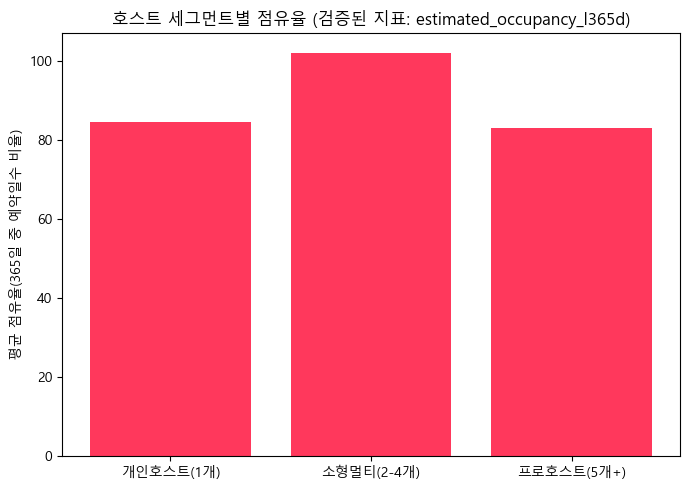

기존 지표(occupancy_rate) 기준:
host_segment
개인호스트(1개)     0.574996
소형멀티(2-4개)    0.481476
프로호스트(5개+)    0.351715
Name: occupancy_rate, dtype: float64

검증된 지표(estimated_occupancy_l365d) 기준:
host_segment
개인호스트(1개)      84.534137
소형멀티(2-4개)    101.851240
프로호스트(5개+)     82.946904
Name: estimated_occupancy_l365d, dtype: float64


In [16]:
seg_validated = df.groupby('host_segment', observed=True)['estimated_occupancy_l365d'].mean()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(seg_validated.index.astype(str), seg_validated.values, color='#FF385C')
ax.set_title('호스트 세그먼트별 점유율 (검증된 지표: estimated_occupancy_l365d)')
ax.set_ylabel('평균 점유율(365일 중 예약일수 비율)')
plt.tight_layout()
plt.savefig('../outputs/q_host_segment_validated.png', dpi=130)
plt.show()

print("기존 지표(occupancy_rate) 기준:")
print(seg)
print()
print("검증된 지표(estimated_occupancy_l365d) 기준:")
print(seg_validated)

### 검증된 지표(estimated_occupancy_l365d)로 재분석

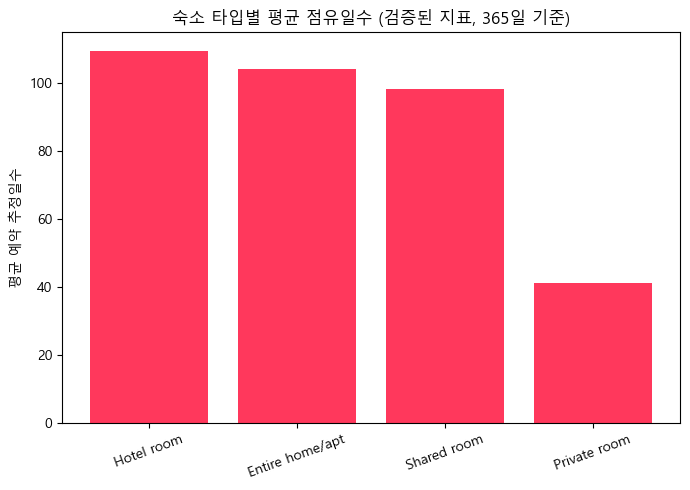

기존 지표(occupancy_rate) 기준:
room_type
Private room       0.521391
Hotel room         0.475262
Entire home/apt    0.377488
Shared room        0.364729
Name: occupancy_rate, dtype: float64

검증된 지표(estimated_occupancy_l365d) 기준:
room_type
Hotel room         109.411765
Entire home/apt    104.070454
Shared room         98.327731
Private room        41.269826
Name: estimated_occupancy_l365d, dtype: float64


In [17]:
rt_validated = df.groupby('room_type')['estimated_occupancy_l365d'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(rt_validated.index, rt_validated.values, color='#FF385C')
ax.set_title('숙소 타입별 평균 점유일수 (검증된 지표, 365일 기준)')
ax.set_ylabel('평균 예약 추정일수')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('../outputs/q1_room_type_validated.png', dpi=130)
plt.show()

print("기존 지표(occupancy_rate) 기준:")
print(rt)
print()
print("검증된 지표(estimated_occupancy_l365d) 기준:")
print(rt_validated)

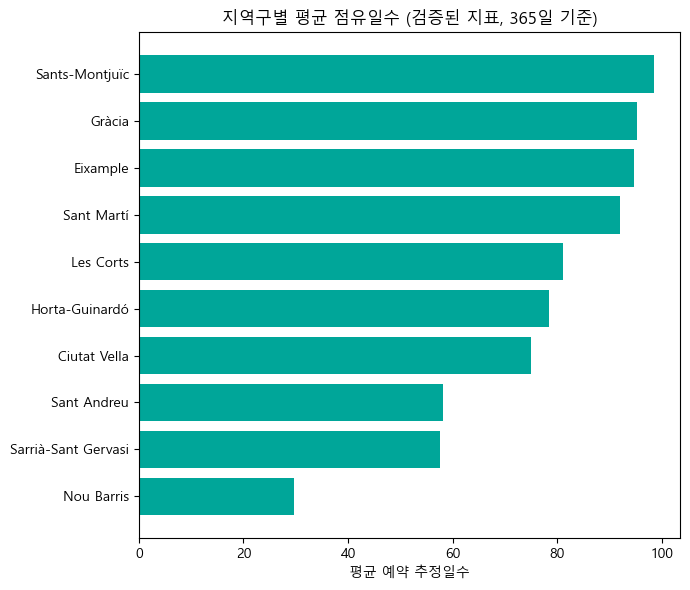

기존 지표(occupancy_rate) 기준:
neighbourhood_group_cleansed
Les Corts              0.477324
Sant Martí             0.447888
Sant Andreu            0.441498
Ciutat Vella           0.436316
Sants-Montjuïc         0.431388
Horta-Guinardó         0.425645
Gràcia                 0.424467
Eixample               0.402134
Sarrià-Sant Gervasi    0.356744
Nou Barris             0.343373
Name: occupancy_rate, dtype: float64

검증된 지표(estimated_occupancy_l365d) 기준:
neighbourhood_group_cleansed
Sants-Montjuïc         98.497238
Gràcia                 95.180820
Eixample               94.553899
Sant Martí             92.039694
Les Corts              81.058104
Horta-Guinardó         78.377095
Ciutat Vella           75.003080
Sant Andreu            58.044444
Sarrià-Sant Gervasi    57.484234
Nou Barris             29.662577
Name: estimated_occupancy_l365d, dtype: float64


In [18]:
ng_validated = df.groupby('neighbourhood_group_cleansed')['estimated_occupancy_l365d'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(ng_validated.index[::-1], ng_validated.values[::-1], color='#00A699')
ax.set_title('지역구별 평균 점유일수 (검증된 지표, 365일 기준)')
ax.set_xlabel('평균 예약 추정일수')
plt.tight_layout()
plt.savefig('../outputs/q5_neighbourhood_validated.png', dpi=130)
plt.show()

print("기존 지표(occupancy_rate) 기준:")
print(ng)
print()
print("검증된 지표(estimated_occupancy_l365d) 기준:")
print(ng_validated)